In [11]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os

import nibabel as nib
import nilearn.plotting as plotting
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import hcp_utils as hcp


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance


import tensorflow as tf
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline


from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



import shap

from mlxtend.feature_selection import SequentialFeatureSelector as SFS






### mmp data 180 regions

In [12]:
open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

file_path = "parcellations"
file_list = os.listdir(file_path)
mmp = {}
ca = {}
for filename in file_list:
    subject_id = filename[4:10]

    if subject_id.isdigit():
        subject_id = int(subject_id)

        if "mmp" in filename:
            mmp_file = np.load(file_path + "/" + filename)
            if mmp_file.shape == (3600, 379):
                mmp[subject_id] = mmp_file
        if "ca" in filename:
            ca_file = np.load(file_path + "/" + filename)
            if ca_file.shape == (3600, 718):
                ca[subject_id] = ca_file

mmp_data = pd.DataFrame({
    'Subject': list(mmp.keys()),
    'Brain_Data': list(mmp.values())  # (3600, 379) arrays
})


mmp_data = subject_data.merge(mmp_data, on='Subject', how='inner')

ca_data = pd.DataFrame({
    'Subject': list(ca.keys()),
    'Brain_Data': list(ca.values())  # (3600, 718) arrays
})


ca_data = subject_data.merge(ca_data, on='Subject', how='inner')

mmp_data["Handedness_Cat"] = mmp_data["Handedness"].apply(lambda x: "Left" if x < 0 else "Right")
mmp_data["Gender_Cat"] = (mmp_data["Gender"] == "M").astype("int")

hand_data = mmp_data[["Subject", "Gender_Cat", "Race", "Handedness", "Handedness_Cat", "Gender"]]


In [13]:
def fisher_z_transform(correlation_matrix):
    corr_matrix = correlation_matrix.copy()
    corr_matrix[corr_matrix == 1.] = 0.999
    return np.arctanh(corr_matrix)

correlation_matrix_list = []
for i in range(mmp_data.shape[0]):
    person = mmp_data["Brain_Data"][i]
    #get matrix
    person_matrix = np.corrcoef(person.T)
    person_matrix = fisher_z_transform(person_matrix)
    #append to list
    correlation_matrix_list.append(person_matrix)
#append to column
mmp_data["correlation_matrix"] = correlation_matrix_list

brain_region = list(hcp.mmp.labels.values())[1:]

brain_data = np.array(mmp_data["Brain_Data"].tolist())
brain_data_mean = brain_data.mean(axis = 1)
brain_df = pd.DataFrame(brain_data_mean, columns = brain_region)
brain_df = pd.concat([mmp_data["Subject"], mmp_data["Handedness"], brain_df], axis = 1)

def feature_row_get(target):
    target_index = brain_region.index(target)
    target_row = mmp_data['correlation_matrix'].apply(lambda x: x[target_index])
    return target_row


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [14]:
feature_1 = feature_row_get("L_SFL")
feature_2 = feature_row_get("L_1")
feature_3 = feature_row_get("L_44")
feature_4 = feature_row_get("L_OFC")
feature_5 = feature_row_get("L_TA2")
feature_6 = feature_row_get("L_PHA1")
feature_7 = feature_row_get("L_TE1a")
feature_8 = feature_row_get("L_DVT")
feature_9 = feature_row_get("L_pOFC")
feature_10 = feature_row_get("R_PEF")
feature_11 = feature_row_get("R_VIP")
feature_12 = feature_row_get("R_1")
feature_13 = feature_row_get("R_11l")
feature_14 = feature_row_get("R_OP4")
feature_15 = feature_row_get("R_OP2-3")
feature_16 = feature_row_get("R_PFcm")
feature_17 = feature_row_get("R_H")
feature_18 = feature_row_get("R_31pd")

feature_data = mmp_data[["Handedness", "Handedness_Cat", "correlation_matrix", "Gender_Cat"]]
feature_data['matrix_mean'] = mmp_data['correlation_matrix'].apply(lambda x: np.mean(x))

feature_data["feature_1"]  = feature_1
feature_data["feature_2"]  = feature_2
feature_data["feature_3"]  = feature_3
feature_data["feature_4"]  = feature_4
feature_data["feature_5"]  = feature_5
feature_data["feature_6"]  = feature_6
feature_data["feature_7"]  = feature_7
feature_data["feature_8"]  = feature_8
feature_data["feature_9"]  = feature_9
feature_data["feature_10"] = feature_10
feature_data["feature_11"] = feature_11
feature_data["feature_12"] = feature_12
feature_data["feature_13"] = feature_13
feature_data["feature_14"] = feature_14
feature_data["feature_15"] = feature_15
feature_data["feature_16"] = feature_16
feature_data["feature_17"] = feature_17
feature_data["feature_18"] = feature_18


def extract_features_2d(row):
    """
    Given a single row of the DataFrame,
    return a 1D numpy array of all features to be used by the model.
    """
    # Example: Flatten correlation_matrix (if it's a 2D 3x3 matrix, that becomes 9 values)
    corr_mat = np.array(row["correlation_matrix"])
    
    # Flatten each 'semi_*' array (each is length 3 in your example)
    
    feature_1 = np.array(row["feature_1"])
    feature_2 = np.array(row["feature_2"])
    feature_3 = np.array(row["feature_3"])
    feature_4 = np.array(row["feature_4"])
    feature_5 = np.array(row["feature_5"])
    feature_6 = np.array(row["feature_6"])
    feature_7 = np.array(row["feature_7"])
    feature_8 = np.array(row["feature_8"])
    feature_9 = np.array(row["feature_9"])
    feature_10 = np.array(row["feature_10"])
    feature_11 = np.array(row["feature_11"])
    feature_12 = np.array(row["feature_12"])
    feature_13 = np.array(row["feature_13"])
    feature_14 = np.array(row["feature_14"])
    feature_15 = np.array(row["feature_15"])
    feature_16 = np.array(row["feature_16"])
    feature_17 = np.array(row["feature_17"])
    feature_18 = np.array(row["feature_18"])


    
    # Concatenate them into one array
    all_features = np.concatenate([
      feature_1,
      feature_2,
      feature_3,
      feature_4,
      feature_5,
      feature_6,
      feature_7,
      feature_8,
      feature_9,
      feature_10,
      feature_11,
      feature_12,
      feature_13,
      feature_14,
      feature_15,
      feature_16,
      feature_17,
      feature_18
    ])
    
    return corr_mat, all_features

feature_data_all = feature_data.copy()

filtered_df = feature_data[(feature_data['Handedness'] > 25) | (feature_data['Handedness'] < -25)]

# Separate into left and right handed
left_handed = filtered_df[filtered_df['Handedness'] < 0]
right_handed = filtered_df[filtered_df['Handedness'] > 0]

# Determine the number of samples to select from the right-handed data
num_samples = min(len(left_handed), len(right_handed))

# Randomly sample from the right-handed data
right_handed_sample = right_handed.sample(n=num_samples, random_state=42)

# Combine the left and right handed data
final_df = pd.concat([left_handed, right_handed_sample])

# Optionally shuffle the final dataframe to mix left and right handed samples
final_df = final_df.sample(frac=1).reset_index(drop=True)

feature_data = final_df

feature_data_all = feature_data_all[(feature_data_all['Handedness'] > 25) | (feature_data_all['Handedness'] < -25)]




A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

#### SCGRegressor

In [15]:


# Example feature extraction function (provided by you)
def extract_features_2d(row):
    """
    Given a single row of the DataFrame,
    return the correlation matrix and a 1D numpy array of all features.
    """
    # Extract correlation matrix (assumed to be a 2D array)
    corr_mat = np.array(row["correlation_matrix"])
    
    # Extract features (each assumed to be a 1D array)
    feature_1 = np.array(row["feature_1"])
    feature_2 = np.array(row["feature_2"])
    feature_3 = np.array(row["feature_3"])
    feature_4 = np.array(row["feature_4"])
    feature_5 = np.array(row["feature_5"])
    feature_6 = np.array(row["feature_6"])
    feature_7 = np.array(row["feature_7"])
    feature_8 = np.array(row["feature_8"])
    feature_9 = np.array(row["feature_9"])
    feature_10 = np.array(row["feature_10"])
    feature_11 = np.array(row["feature_11"])
    feature_12 = np.array(row["feature_12"])
    feature_13 = np.array(row["feature_13"])
    feature_14 = np.array(row["feature_14"])
    feature_15 = np.array(row["feature_15"])
    feature_16 = np.array(row["feature_16"])
    feature_17 = np.array(row["feature_17"])
    feature_18 = np.array(row["feature_18"])
    
    # Concatenate the features into one long 1D array
    all_features = np.concatenate([
        feature_1,
        feature_2,
        feature_3,
        feature_4,
        feature_5,
        feature_6,
        feature_7,
        feature_8,
        feature_9,
        feature_10,
        feature_11,
        feature_12,
        feature_13,
        feature_14,
        feature_15,
        feature_16,
        feature_17,
        feature_18
    ])
    
    return corr_mat, all_features

# ------------------------------------------------------------------
# Suppose you have a DataFrame 'df' that contains:
#   - "correlation_matrix": a 2D array (e.g., 3x3)
#   - "feature_1" to "feature_18": each a 1D array of numbers
#   - "target": the target variable for regression
# For example, you might load your DataFrame like:
# df = pd.read_csv("your_data.csv")
# (Make sure the arrays are stored in a way that Python can interpret them properly.)

# ------------------------------------------------------------------
# Build the feature matrix by applying extract_features_2d to each row.
# Here we choose to use the concatenated features (all_features) for regression.
# (If you also want to include information from the correlation matrix, you could flatten and append it.)

# Option 1: Using DataFrame.apply with np.vstack
X_features = np.vstack(feature_data_all.apply(lambda row: extract_features_2d(row)[1], axis=1).values)
y = feature_data_all['Handedness'].values 

# ------------------------------------------------------------------
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state= 25
)

# Create and train the XGBRegressor
model = XGBRegressor(objective='reg:squarederror')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)



Mean Squared Error: 1750.7853165313081


In [16]:
y_pred

array([ 6.80128860e+01,  8.07317123e+01,  8.48368073e+01,  7.94613647e+01,
       -3.18323827e+00,  7.76900787e+01,  8.37512589e+01,  6.85073318e+01,
        6.37156601e+01,  1.35503025e+01,  6.84522324e+01,  9.52214813e+01,
        8.03537292e+01,  9.44114075e+01,  6.46823578e+01,  4.10930710e+01,
        8.55948410e+01, -8.60167146e-02,  7.97863007e+01,  5.63570290e+01,
        8.20764694e+01,  7.45775452e+01,  8.80283585e+01,  5.21753731e+01,
        7.70561752e+01,  7.53595276e+01,  8.37019882e+01,  9.12525635e+01,
        9.58616638e+01,  8.96035156e+01,  6.76428375e+01,  4.47298965e+01,
        8.96436691e+01], dtype=float32)

In [17]:
y_test

array([ 90, 100, 100, 100,  75,  50,  95,  70,  80,  95,  40,  80,  80,
        30,  40,  70,  90, 100,  90, -30,  95,  50,  60,  85,  90, -35,
        85,  80, 100, 100,  80,  95,  75])

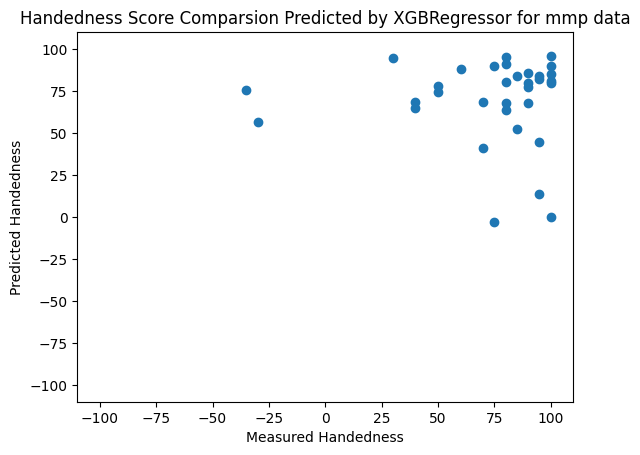

In [18]:
plt.scatter(x = y_test, y = y_pred)
plt.xlim(-110, 110)
plt.ylim(-110, 110)
plt.xlabel('Measured Handedness')
plt.ylabel('Predicted Handedness')
plt.title("Handedness Score Comparsion Predicted by XGBRegressor for mmp data")
plt.show()

#### Polynomial

In [19]:


# Example feature extraction function
def flatten_features(row):
    """
    Given a single row of the DataFrame,
    return the correlation matrix and a 1D numpy array of all features.
    """
    # Extract the correlation matrix (assumed to be a 2D array)
    corr_mat = np.array(row["correlation_matrix"])
    
    # Extract each feature (assumed to be a 1D array)
    feature_1 = np.array(row["feature_1"])
    feature_2 = np.array(row["feature_2"])
    feature_3 = np.array(row["feature_3"])
    feature_4 = np.array(row["feature_4"])
    feature_5 = np.array(row["feature_5"])
    feature_6 = np.array(row["feature_6"])
    feature_7 = np.array(row["feature_7"])
    feature_8 = np.array(row["feature_8"])
    feature_9 = np.array(row["feature_9"])
    feature_10 = np.array(row["feature_10"])
    feature_11 = np.array(row["feature_11"])
    feature_12 = np.array(row["feature_12"])
    feature_13 = np.array(row["feature_13"])
    feature_14 = np.array(row["feature_14"])
    feature_15 = np.array(row["feature_15"])
    feature_16 = np.array(row["feature_16"])
    feature_17 = np.array(row["feature_17"])
    feature_18 = np.array(row["feature_18"])
    
    # Concatenate all features into one long 1D array
    all_features = np.concatenate([
        feature_1,
        feature_2,
        feature_3,
        feature_4,
        feature_5,
        feature_6,
        feature_7,
        feature_8,
        feature_9,
        feature_10,
        feature_11,
        feature_12,
        feature_13,
        feature_14,
        feature_15,
        feature_16,
        feature_17,
        feature_18
    ])
    
    return all_features

# ------------------------------------------------------------------
# Assuming you have a DataFrame 'df' that contains:
#   - "correlation_matrix": a 2D array (e.g., 3x3)
#   - "feature_1" to "feature_18": each a 1D array of numbers
#   - "target": the target variable for regression
# For example, you might load your DataFrame like:
# df = pd.read_csv("your_data.csv")
# (Make sure that the arrays are stored or parsed correctly.)

# Build the feature matrix using the extract_features_2d function.
# Here, we choose to use only the concatenated features (all_features) for regression.
X_features = np.vstack(feature_data_all.apply(lambda row: flatten_features(row)[1], axis=1).values)
y = feature_data_all['Handedness'].values 

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state= 25
)

# Define the degree of the polynomial features. You can change this value as needed.
degree = 2

# Create a pipeline that first creates polynomial features then fits a linear regression model.
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 1111.9018308359323


In [20]:
y_pred

array([77.28501788, 71.11861075, 71.60292843, 72.39491791, 72.64037918,
       73.47659323, 72.43020511, 73.66348103, 73.24962795, 79.21631627,
       78.64993447, 72.35262239, 71.57855584, 74.67988431, 71.60073135,
       81.13524221, 70.45043344, 72.46237534, 76.5704035 , 70.68089783,
       73.89388258, 72.77140803, 78.35502227, 72.36079636, 75.30086706,
       77.19720514, 70.60256133, 74.14840564, 70.67607686, 75.48912921,
       70.45148048, 72.76014766, 73.6768237 ])

In [21]:
y_test

array([ 90, 100, 100, 100,  75,  50,  95,  70,  80,  95,  40,  80,  80,
        30,  40,  70,  90, 100,  90, -30,  95,  50,  60,  85,  90, -35,
        85,  80, 100, 100,  80,  95,  75])

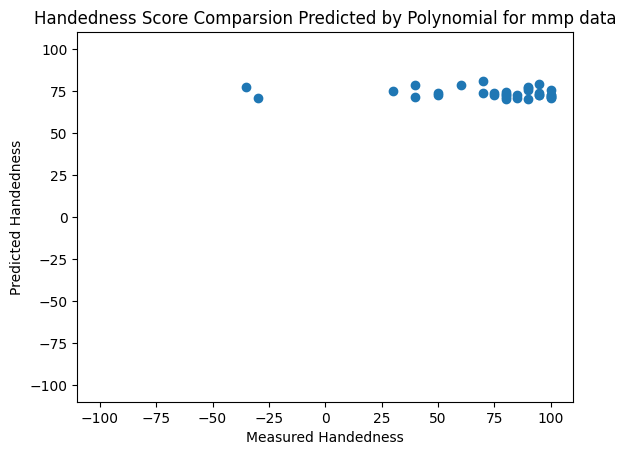

In [22]:
plt.scatter(x = y_test, y = y_pred)
plt.xlim(-110, 110)
plt.ylim(-110, 110)
plt.xlabel('Measured Handedness')
plt.ylabel('Predicted Handedness')
plt.title("Handedness Score Comparsion Predicted by Polynomial for mmp data")
plt.show()

#### SGDRegressor

In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


# ------------------------------------------------------------------
# Assume you have a DataFrame 'df' with the following columns:
#   - "correlation_matrix": a 2D array (e.g., 3x3)
#   - "feature_1" to "feature_18": each a 1D array of numbers
#   - "target": the target variable for regression

# Build the feature matrix using the extract_features_2d function.
# We use only the concatenated features (all_features) for regression.
X_features = np.vstack(feature_data_all.apply(lambda row: flatten_features(row)[1], axis=1).values)
y = feature_data_all['Handedness'].values  # Make sure 'target' is your target column

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state= 25
)

# Optionally, create a pipeline with scaling and SGDRegressor.
# SGDRegressor is sensitive to feature scaling.
pipeline = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3)
)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 1060.2729392715817


In [24]:
y_pred

array([75.88623873, 72.28279545, 72.79500889, 73.43801728, 73.60926266,
       74.13030925, 73.46327245, 67.02413738, 73.99686983, 76.58190902,
       64.87400576, 73.40744362, 72.77216154, 74.76646016, 72.7929592 ,
       77.20057079, 70.4479728 , 73.48610219, 75.60422741, 69.64865629,
       74.36321928, 73.69676212, 76.28225176, 73.41337842, 75.0591558 ,
       75.85240561, 71.43491734, 74.4984017 , 71.60199846, 75.14414411,
       70.82388998, 73.68934089, 74.24394178])

In [25]:
y_test

array([ 90, 100, 100, 100,  75,  50,  95,  70,  80,  95,  40,  80,  80,
        30,  40,  70,  90, 100,  90, -30,  95,  50,  60,  85,  90, -35,
        85,  80, 100, 100,  80,  95,  75])

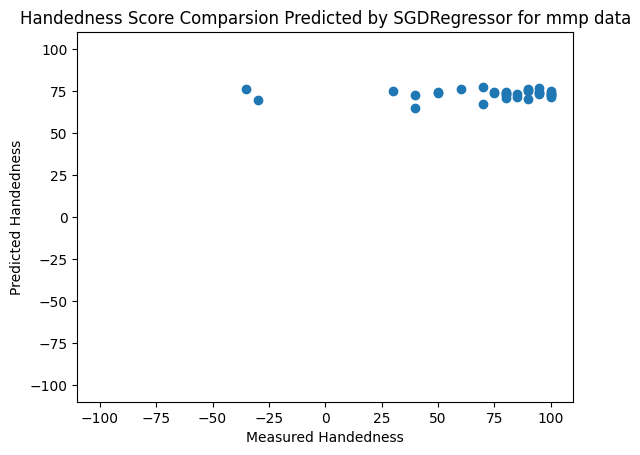

In [26]:
plt.scatter(x = y_test, y = y_pred)
plt.xlim(-110, 110)
plt.ylim(-110, 110)
plt.xlabel('Measured Handedness')
plt.ylabel('Predicted Handedness')
plt.title("Handedness Score Comparsion Predicted by SGDRegressor for mmp data")
plt.show()

### HCP data for d50

In [27]:
from nilearn import image, plotting
from atlasreader.atlasreader import read_atlas_peak

"""
available reference atlases
---------------------------
    "aal",
    "aicha",
    "desikan_killiany",
    "destrieux",
    "harvard_oxford",
    "juelich",
    "marsatlas",
    "neuromorphometrics",
    "talairach_ba",
    "talairach_gyrus",
 """

atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d50.ica/melodic_IC_sum.nii.gz", "99.5%") 
atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
brain_region = []
print("BRAIN REGIONS:\n--------------")
for atlas_coord in atlas_coords:
    region = read_atlas_peak("harvard_oxford", atlas_coord)
    print(region)
    brain_region += [region]

#select the correct region with largest probability given from the library
brain_region = [
    max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
]
brain_region

BRAIN REGIONS:
--------------
[[50.0, 'Right_Cuneal_Cortex'], [24.0, 'Left_Cuneal_Cortex'], [7.0, 'Right_Precuneous_Cortex']]
[[71.0, 'Left_Occipital_Pole']]
[[43.0, 'Right_Occipital_Pole'], [12.0, 'Right_Lateral_Occipital_Cortex_superior_division']]
[[37.0, 'Right_Lateral_Occipital_Cortex_superior_division'], [23.0, 'Right_Lateral_Occipital_Cortex_inferior_division'], [5.0, 'Right_Occipital_Pole']]
[[53.0, 'Left_Lateral_Occipital_Cortex_superior_division'], [21.0, 'Left_Angular_Gyrus']]
[[71.0, 'Left_Lateral_Occipital_Cortex_superior_division']]
[[53.0, 'Right_Supramarginal_Gyrus_posterior_division'], [22.0, 'Right_Angular_Gyrus']]
[[79.0, 'Right_Lateral_Occipital_Cortex_superior_division']]
[[73.0, 'Left_Supramarginal_Gyrus_anterior_division'], [13.0, 'Left_Supramarginal_Gyrus_posterior_division']]
[[62.0, 'Right_Lateral_Occipital_Cortex_superior_division'], [21.0, 'Right_Angular_Gyrus']]
[[73.0, 'Left_Lateral_Occipital_Cortex_superior_division']]
[[38.0, 'Left_Superior_Frontal_Gyrus

['Right_Cuneal_Cortex',
 'Left_Occipital_Pole',
 'Right_Occipital_Pole',
 'Right_Lateral_Occipital_Cortex_superior_division',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Right_Supramarginal_Gyrus_posterior_division',
 'Right_Lateral_Occipital_Cortex_superior_division',
 'Left_Supramarginal_Gyrus_anterior_division',
 'Right_Lateral_Occipital_Cortex_superior_division',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Left_Superior_Frontal_Gyrus',
 'Left_Lateral_Occipital_Cortex_superior_division',
 'Right_Supramarginal_Gyrus_anterior_division',
 'Left_Angular_Gyrus',
 'Right_Occipital_Pole',
 'Left_Angular_Gyrus',
 'Left_Precuneous_Cortex',
 'Right_Supramarginal_Gyrus_anterior_division',
 'Right_Occipital_Fusiform_Gyrus',
 'Right_Middle_Frontal_Gyrus',
 'Right_Lateral_Occipital_Cortex_inferior_division',
 'Left_Precentral_Gyrus',
 'Right_Occipital_Pole',
 'Left_Occipital_Pole',
 'Left_Inferior_Frontal_Gyrus_pars_triangula

In [28]:
open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d50_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

hand_data = data[["Subject", "Gender", "Race", "Handedness"]]

correlation_matrix_list = []
for i in range(data.shape[0]):
    person = data["Brain_Data"][i]
    #get matrix
    person_matrix = np.corrcoef(person.T)
    #append to list
    correlation_matrix_list.append(person_matrix)
#append to column
data["correlation_matrix"] = correlation_matrix_list

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [29]:
data = data[(data['Handedness'] > 25) | (data['Handedness'] < -25)]

def feature_row_get(target):
    target_index = brain_region.index(target)
    target_row = data['correlation_matrix'].apply(lambda x: x[target_index])
    return target_row

semi_MTG = feature_row_get("Right_Planum_Temporale")

semi_ACC = feature_row_get("Left_Superior_Frontal_Gyrus")

semi_MCC_1 = feature_row_get("Left_Precuneous_Cortex")
semi_MCC_2 = feature_row_get("Left_Precentral_Gyrus")

semi_ANG_1 = feature_row_get("Right_Angular_Gyrus")

semi_AMYG_1 = feature_row_get("Left_Thalamus")
semi_AMYG_2 = feature_row_get("Right_Putamen")
semi_AMYG_3 = feature_row_get("Right_Caudate")
semi_AMYG_4 = feature_row_get("Brain-Stem")

feature_data = data[["Handedness", "correlation_matrix"]]
feature_data['matrix_mean'] = data['correlation_matrix'].apply(lambda x: np.mean(x))
feature_data["semi_MTG"] = semi_MTG
feature_data["semi_ACC"] = semi_ACC
feature_data["semi_MCC_1"] = semi_MCC_1
feature_data["semi_MCC_2"] = semi_MCC_2

feature_data["semi_ANG_1"] = semi_ANG_1

feature_data["semi_AMYG_1"] = semi_AMYG_1
feature_data["semi_AMYG_2"] = semi_AMYG_2
feature_data["semi_AMYG_3"] = semi_AMYG_3
feature_data["semi_AMYG_4"] = semi_AMYG_4

def flatten_features(row):
    """
    Given a single row of the DataFrame,
    return a 1D numpy array of all features to be used by the model.
    """
    # Example: Flatten correlation_matrix (if it's a 2D 3x3 matrix, that becomes 9 values)
    
    # Flatten each 'semi_*' array (each is length 3 in your example)
    semi_MTG = np.array(row["semi_MTG"])
    semi_ACC = np.array(row["semi_ACC"])
    semi_MCC_1 = np.array(row["semi_MCC_1"])
    semi_MCC_2 = np.array(row["semi_MCC_2"])

    semi_ANG_1 = np.array(row["semi_ANG_1"])
    semi_AMYG_1 = np.array(row["semi_AMYG_1"])
    semi_AMYG_2 = np.array(row["semi_AMYG_2"])
    semi_AMYG_3 = np.array(row["semi_AMYG_3"])
    semi_AMYG_4 = np.array(row["semi_AMYG_4"])


    
    # Concatenate them into one array
    all_features = np.concatenate([
        semi_MTG, semi_ACC, semi_MCC_1, semi_MCC_2,
        semi_ANG_1, semi_AMYG_1, semi_AMYG_2, semi_AMYG_3, semi_AMYG_4
    ])
    
    return all_features


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

#### XGBRegressor

In [30]:

# Option 1: Using DataFrame.apply with np.vstack
X_features = np.vstack(feature_data.apply(lambda row: flatten_features(row), axis=1).values)
y = data['Handedness'].values 

# ------------------------------------------------------------------
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state= 25
)

# Create and train the XGBRegressor
model = XGBRegressor(objective='reg:squarederror')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 2523.9132576839584


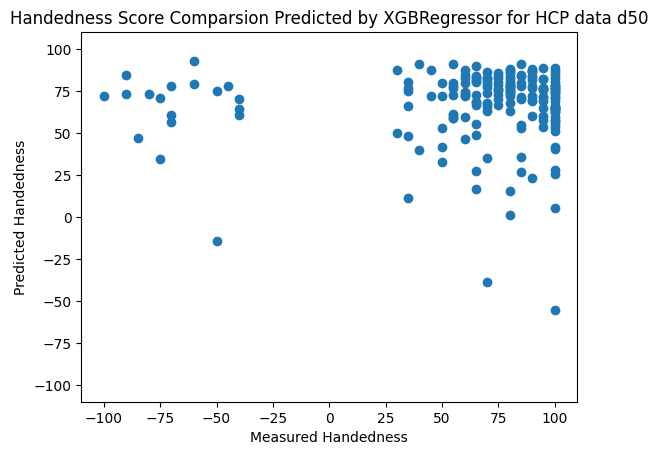

In [31]:
plt.scatter(x = y_test, y = y_pred)
plt.xlim(-110, 110)
plt.ylim(-110, 110)
plt.xlabel('Measured Handedness')
plt.ylabel('Predicted Handedness')
plt.title("Handedness Score Comparsion Predicted by XGBRegressor for HCP data d50")
plt.show()

#### Polynomial

In [32]:
X_features = np.vstack(feature_data.apply(lambda row: flatten_features(row), axis=1).values)
y = feature_data['Handedness'].values 

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state= 25
)

# Define the degree of the polynomial features. You can change this value as needed.
degree = 2

# Create a pipeline that first creates polynomial features then fits a linear regression model.
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


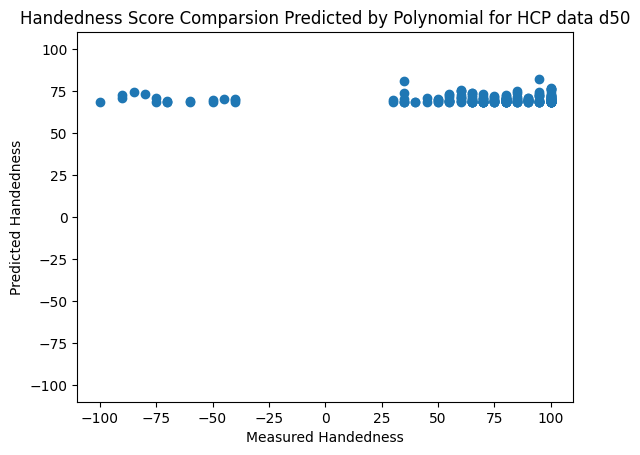

In [ ]:
plt.scatter(x = y_test, y = y_pred)
plt.xlim(-110, 110)
plt.ylim(-110, 110)
plt.xlabel('Measured Handedness')
plt.ylabel('Predicted Handedness')
plt.title("Handedness Score Comparsion Predicted by Polynomial for HCP data d50")
plt.show()

#### SGDRegressor

In [ ]:
X_features = np.vstack(feature_data.iloc[:, 3:].apply(lambda row: flatten_features(row), axis=1).values)
y = feature_data['Handedness'].values  # Make sure 'target' is your target column

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state= 25
)

# Optionally, create a pipeline with scaling and SGDRegressor.
# SGDRegressor is sensitive to feature scaling.
pipeline = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3)
)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 2854.8676617286033


In [ ]:
y_pred

array([ 36.54002655,  46.49842116,  73.69484876,  61.81106743,
       132.4888235 ,  39.86436837,  80.67774913,  60.21996906,
        74.45513694,  47.75463391,  82.64194772,  39.30331079,
       106.29464474,  76.07598372,  91.63749308,  53.95883489,
        71.36236924,  51.06896506,  90.1150117 ,  36.01633342,
        77.18753302,  69.57554806, 115.39793341,  98.92021133,
        85.76115805,  42.22917393,  68.80406765,  76.76361139,
         3.55614134,  76.26512327,  70.77663908,  59.83348657,
       122.95104203,  50.09947463,  50.53380478,  59.38573862,
        73.54142472,  55.16107532, 128.85773184,  46.10506507,
        75.58527629,  79.89628792,  52.01313306, -23.05389697,
        87.85234328, 116.28142568,  62.62067894,  55.99924692,
        54.03186617,  63.34700919, 136.07956473, 111.34600297,
       144.41603532, 153.00511163,  98.70896771,  11.0382298 ,
       143.39066653,  94.71464077,  43.03692678,  55.83684244,
        -9.49651268, 116.200854  , 121.56154649, 102.20

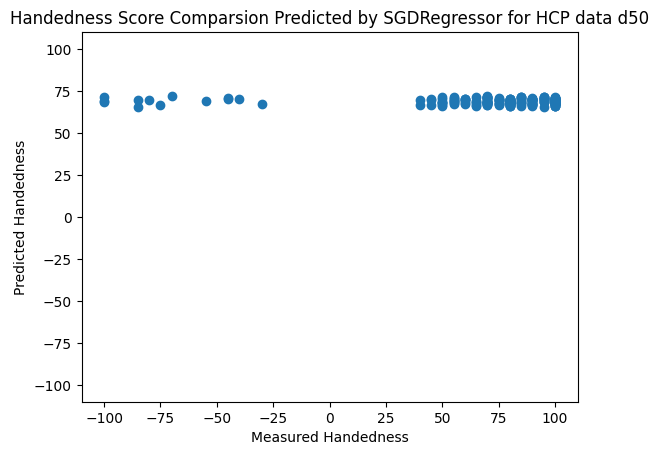

In [ ]:
plt.scatter(x = y_test, y = y_pred)
plt.xlim(-110, 110)
plt.ylim(-110, 110)
plt.xlabel('Measured Handedness')
plt.ylabel('Predicted Handedness')
plt.title("Handedness Score Comparsion Predicted by SGDRegressor for HCP data d50")
plt.show()